In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'L1VzZXJzL2FsYWwvRGVza3RvcC9jb2RlL2NyYWJieW1ldHJpY3MvZG9jcy9hYmxhdGlvbnM='
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"/Users/alal/.local/share/uv/python/cpython-3.12.9-macos-aarch64-none/lib/python3.12/importlib/_bootstrap.py": 1743382022.7735002, "/Users/alal/.local/share/uv/python/cpython-3.12.9-macos-aarch64-none/lib/python3.12/importlib/_bootstrap_external.py": 1743382022.7737157, "/Users/alal/.local/share/uv/python/cpython-3.12.9-macos-aarch64-none/lib/python3.12/zipimport.py": 1743382022.8471594, "/Users/alal/.local/share/uv/python/cpython-3.12.9-macos-aarch64-none/lib/python3.12/codecs.py": 1743382022.716922, "/Users/alal/.local/share/uv/python/cpython-3.12.9-macos-aarch64-none/lib/python3.12/encodings/aliases.py": 1743382022.7266889, "/Users/alal/.local/share/uv/python/cpython-3.12.9-macos-aarch64-none/lib/python3.12/encodings/__init__.py": 1743382022.7262201, "/Users/alal/.local/share/uv/python/cpython-3.12.9-macos-aarch64-none/lib/python3.12/encodings/utf_8.py": 1743382022.7358487, "/Users/alal/.local/share/uv/python/cpython-3.12.9-macos-aarch64-none/lib/python3.12/abc.py": 1743382022.7091

In [2]:
from html import escape

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, display

np.set_printoptions(precision=4, suppress=True)


def html_table(headers, rows):
    parts = ["<table>", "<thead>", "<tr>"]
    parts.extend(f"<th>{escape(str(h))}</th>" for h in headers)
    parts.extend(["</tr>", "</thead>", "<tbody>"])
    for row in rows:
        parts.append("<tr>")
        parts.extend(f"<td>{cell}</td>" for cell in row)
        parts.append("</tr>")
    parts.extend(["</tbody>", "</table>"])
    return "".join(parts)


def expit(z):
    z = np.clip(z, -35.0, 35.0)
    return 1.0 / (1.0 + np.exp(-z))


def add_intercept(x):
    return np.column_stack([np.ones(x.shape[0]), x])


def make_folds(n, k, rng):
    idx = rng.permutation(n)
    return [fold for fold in np.array_split(idx, k) if fold.size]

In [3]:
def semipar_did_dgp(n=200, p=100, s=5, theta=3.0, rho=0.0, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    gamma = np.r_[np.arange(s, 0, -1) / s, np.zeros(p - s)]
    x = rng.normal(size=(n, p))
    e = expit(x @ gamma)
    d = rng.binomial(1, e, size=n).astype(float)
    beta = gamma + 0.5
    eps = rng.normal(0.0, 0.1, size=n)

    y00 = x @ beta + eps
    y01 = y00 + 1.0 + rho * e + eps
    y11 = theta + y01 + eps

    y0 = y00
    y1 = y01 * (1.0 - d) + y11 * d
    return {"y1": y1, "y0": y0, "d": d, "x": x, "e": e, "theta": theta, "rho": rho}


example = semipar_did_dgp(rho=2.0, rng=np.random.default_rng(42))
display(
    HTML(
        html_table(
            ["Quantity", "Value"],
            [
                ["N", example["x"].shape[0]],
                ["p", example["x"].shape[1]],
                ["Treated share", f"{example['d'].mean():.3f}"],
                ["Mean propensity", f"{example['e'].mean():.3f}"],
                ["True ATT", f"{example['theta']:.3f}"],
            ],
        )
    )
)

Quantity,Value
N,200
p,100
Treated share,0.475
Mean propensity,0.533
True ATT,3.000


In [4]:
def ridge_fit(x, y, penalty=1.0):
    z = add_intercept(x)
    gram = z.T @ z
    ridge = np.eye(gram.shape[0]) * penalty
    ridge[0, 0] = 0.0
    return np.linalg.solve(gram + ridge, z.T @ y)


def ridge_predict(x, beta):
    return add_intercept(x) @ beta


def logistic_ridge_fit(x, y, penalty=1.0, max_iter=40):
    z = add_intercept(x)
    beta = np.zeros(z.shape[1])
    ridge = np.eye(z.shape[1]) * penalty
    ridge[0, 0] = 0.0
    for _ in range(max_iter):
        eta = z @ beta
        p = expit(eta)
        w = np.clip(p * (1.0 - p), 1e-5, None)
        grad = z.T @ (p - y) + ridge @ beta
        hess = z.T @ (z * w[:, None]) + ridge
        step = np.linalg.solve(hess, grad)
        beta -= step
        if np.max(np.abs(step)) < 1e-6:
            break
    return beta


def logistic_predict(x, beta, clip=0.02):
    return np.clip(expit(add_intercept(x) @ beta), clip, 1.0 - clip)


def crossfit_predict(x, y, fit_fn, pred_fn, penalty, k, rng, subset=None):
    n = x.shape[0]
    pred = np.zeros(n)
    if subset is None:
        subset = np.arange(n)
    subset = np.asarray(subset)
    folds = make_folds(subset.size, k, rng)
    for fold in folds:
        test = subset[fold]
        train = np.setdiff1d(subset, test, assume_unique=False)
        beta = fit_fn(x[train], y[train], penalty)
        pred[test] = pred_fn(x[test], beta)
    return pred


def two_period_did(d, y1, y0):
    return (y1[d == 1].mean() - y0[d == 1].mean()) - (y1[d == 0].mean() - y0[d == 0].mean())


def om_did(x, d, y1, y0, xfit=False, penalty=1.0, rng=None):
    rng = np.random.default_rng(0) if rng is None else rng
    treated = np.flatnonzero(d == 1.0)
    control = np.flatnonzero(d == 0.0)
    preds = []
    for y, group in [(y1, treated), (y1, control), (y0, treated), (y0, control)]:
        beta = ridge_fit(x[group], y[group], penalty)
        pred = ridge_predict(x, beta)
        if xfit:
            pred[group] = crossfit_predict(x, y, ridge_fit, ridge_predict, penalty, 3, rng, subset=group)[group]
        preds.append(pred)
    m1, m2, m3, m4 = preds
    return float(np.mean((m1 - m2) - (m3 - m4)))


def propensity_hat(x, d, xfit=False, penalty=1.0, rng=None):
    if not xfit:
        beta = logistic_ridge_fit(x, d, penalty)
        return logistic_predict(x, beta)
    rng = np.random.default_rng(0) if rng is None else rng
    return crossfit_predict(x, d, logistic_ridge_fit, logistic_predict, penalty, 3, rng)


def ipw_did(x, d, y1, y0, xfit=False, penalty=1.0, rng=None):
    ehat = propensity_hat(x, d, xfit=xfit, penalty=penalty, rng=rng)
    delta = y1 - y0
    score = (d - ehat) / (d.mean() * (1.0 - ehat))
    return float(np.mean(score * delta))


def aipw_did(x, d, y1, y0, xfit=False, penalty=1.0, rng=None):
    rng = np.random.default_rng(0) if rng is None else rng
    ehat = propensity_hat(x, d, xfit=xfit, penalty=penalty, rng=rng)
    delta = y1 - y0
    control = np.flatnonzero(d == 0.0)
    beta = ridge_fit(x[control], delta[control], penalty)
    mhat = ridge_predict(x, beta)
    if xfit:
        mhat[control] = crossfit_predict(x, delta, ridge_fit, ridge_predict, penalty, 3, rng, subset=control)[control]
    score = (d - ehat) / (d.mean() * (1.0 - ehat))
    return float(np.mean(score * (delta - mhat)))


def estimate_all(draw, penalty=1.0, rng=None):
    y1, y0, d, x = draw["y1"], draw["y0"], draw["d"], draw["x"]
    rng = np.random.default_rng(0) if rng is None else rng
    return {
        "naive": float(y1[d == 1].mean() - y1[d == 0].mean()),
        "did": two_period_did(d, y1, y0),
        "om": om_did(x, d, y1, y0, xfit=False, penalty=penalty, rng=rng),
        "omXF": om_did(x, d, y1, y0, xfit=True, penalty=penalty, rng=rng),
        "ipw": ipw_did(x, d, y1, y0, xfit=False, penalty=penalty, rng=rng),
        "ipwXF": ipw_did(x, d, y1, y0, xfit=True, penalty=penalty, rng=rng),
        "aipw": aipw_did(x, d, y1, y0, xfit=False, penalty=penalty, rng=rng),
        "aipwXF": aipw_did(x, d, y1, y0, xfit=True, penalty=penalty, rng=rng),
    }


trial = estimate_all(semipar_did_dgp(rho=0.0, rng=np.random.default_rng(7)), rng=np.random.default_rng(8))
display(HTML(html_table(["Estimator", "Estimate"], [[k, f"{v:.3f}"] for k, v in trial.items()])))

Estimator,Estimate
naive,5.252
did,3.015
om,2.971
omXF,3.295
ipw,3.657
ipwXF,-6.424
aipw,3.041
aipwXF,3.181


In [5]:
def summarize(vals, truth):
    vals = np.asarray(vals)
    err = vals - truth
    return {
        "mean": float(vals.mean()),
        "bias": float(err.mean()),
        "mab": float(abs(err.mean())),
        "sd": float(vals.std(ddof=1)),
        "mse": float(np.mean(err**2)),
    }


def run_mc(rhos=(0.0, 2.0), reps=150, seed=20260516):
    rng = np.random.default_rng(seed)
    rows = []
    draws = {rho: {name: [] for name in ["naive", "did", "om", "omXF", "ipw", "ipwXF", "aipw", "aipwXF"]} for rho in rhos}
    for rho in rhos:
        for _ in range(reps):
            draw = semipar_did_dgp(rho=rho, rng=rng)
            est = estimate_all(draw, penalty=1.0, rng=rng)
            for name, value in est.items():
                draws[rho][name].append(value)
        for name, vals in draws[rho].items():
            rows.append({"rho": rho, "estimator": name, **summarize(vals, 3.0)})
    return rows, draws


mc_rows, mc_draws = run_mc()

for rho in [0.0, 2.0]:
    display(HTML(f"<h4>rho = {rho:g}</h4>"))
    display(
        HTML(
            html_table(
                ["Estimator", "Mean", "Bias", "Mean Absolute Bias", "SD", "MSE"],
                [
                    [
                        r["estimator"],
                        f"{r['mean']:.3f}",
                        f"{r['bias']:+.3f}",
                        f"{r['mab']:.3f}",
                        f"{r['sd']:.3f}",
                        f"{r['mse']:.3f}",
                    ]
                    for r in mc_rows
                    if r["rho"] == rho
                ],
            )
        )
    )

Estimator,Mean,Bias,Mean Absolute Bias,SD,MSE
naive,5.601,+2.601,2.601,0.777,7.366
did,3.002,+0.002,0.002,0.021,0.000
om,3.000,-0.000,0.000,0.048,0.002
omXF,3.010,+0.010,0.010,0.296,0.087
ipw,3.762,+0.762,0.762,0.106,0.593
ipwXF,-4.864,-7.864,7.864,2.310,67.149
aipw,3.008,+0.008,0.008,0.046,0.002
aipwXF,3.041,+0.041,0.041,0.275,0.077


Estimator,Mean,Bias,Mean Absolute Bias,SD,MSE
naive,6.124,+3.124,3.124,0.812,10.412
did,3.590,+0.590,0.590,0.070,0.352
om,3.122,+0.122,0.122,0.063,0.019
omXF,3.117,+0.117,0.117,0.261,0.082
ipw,4.831,+1.831,1.831,0.333,3.465
ipwXF,-12.042,-15.042,15.042,4.117,243.086
aipw,3.117,+0.117,0.117,0.082,0.020
aipwXF,1.732,-1.268,1.268,0.816,2.267


/var/folders/q6/krvpk33x13b1r8q4rm03p7240000gn/T/ipykernel_41756/3102296031.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=order, showfliers=False)
/var/folders/q6/krvpk33x13b1r8q4rm03p7240000gn/T/ipykernel_41756/3102296031.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=order, showfliers=False)


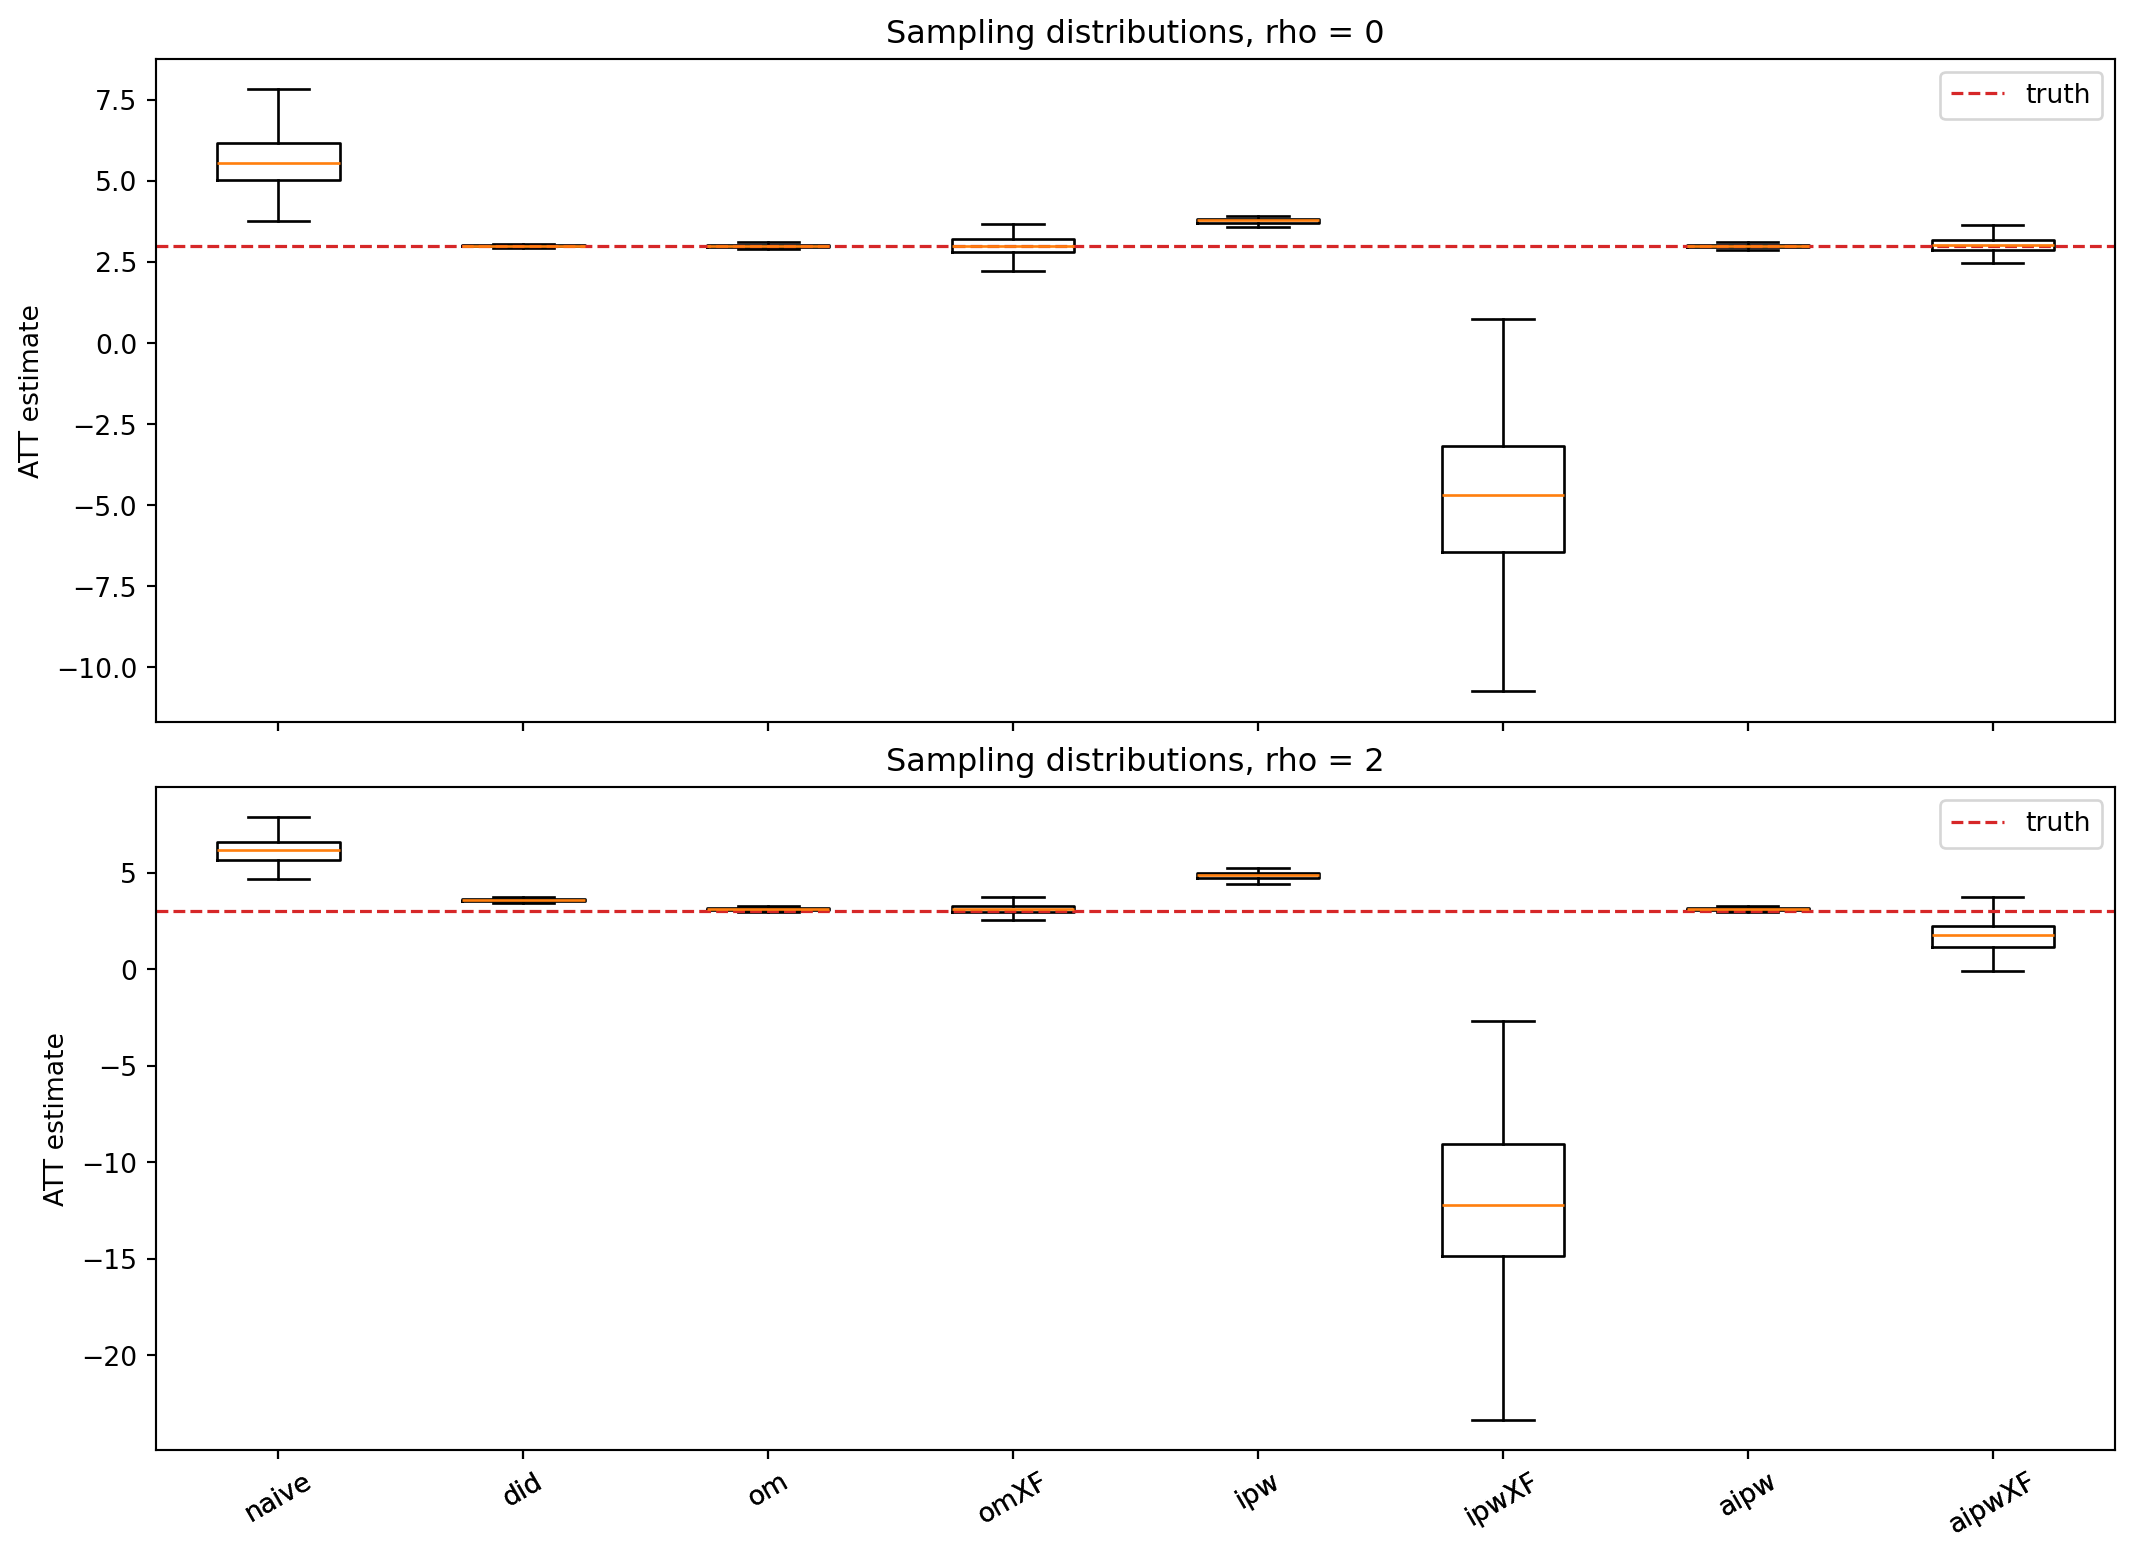

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), constrained_layout=True, sharex=True)
order = ["naive", "did", "om", "omXF", "ipw", "ipwXF", "aipw", "aipwXF"]
for ax, rho in zip(axes, [0.0, 2.0]):
    data = [mc_draws[rho][name] for name in order]
    ax.boxplot(data, labels=order, showfliers=False)
    ax.axhline(3.0, color="tab:red", linestyle="--", linewidth=1.2, label="truth")
    ax.set_title(f"Sampling distributions, rho = {rho:g}")
    ax.set_ylabel("ATT estimate")
    ax.legend(loc="upper right")
axes[-1].tick_params(axis="x", rotation=30)
plt.show()